# p sweep plots for pruning + basis reuse

This notebook plots the currently available results for the pruning + basis reuse method only.

- Figure 1: total execution time for each p as a stacked bar chart. The pruning-time component and the fastest p are highlighted.
- Figure 2: pruning rejection rate and pruning time for each p.

The default circuits are gf2^9_mult, ham15-med, and gf2^10_mult. Results are read from the available detailed summaries. The point p=0 denotes the basis-reuse baseline without pruning, and p is displayed as a normalized ratio between 0 and 1.

In [99]:
from pathlib import Path
import csv
import os
import re

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

cwd = Path.cwd().resolve()
REPO = cwd.parent if cwd.name == "figures" else cwd
FIG_DIR = REPO / "figures"

DETAIL_SUMMARIES = [
    REPO / "forme" / "sketch_experiments" / "aa_sketch_detail_20260618_032309" / "summary.csv",
    REPO / "forme" / "sketch_experiments" / "aa_sketch_detail_20260619_084626" / "summary.csv",
]
CIRCUITS = [
    ("gf2^9_mult.tfc", "gf2^9_mult"),
    ("ham15-med.tfc","ham15-med"),
    ("gf2^10_mult.tfc", "gf2^10_mult"),
    #("barenco_tof_10.tfc", "barenco_tof_10"),
]

P_ORDER = [0, 3, 5, 8, 10, 13, 15, 20, 25, 30]

plt.rcParams.update({
    "font.family": "Noto Sans CJK JP",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

In [100]:
def to_float(value, default=None):
    if value is None or value == "":
        return default
    return float(value)


def to_int(value, default=None):
    if value is None or value == "":
        return default
    return int(float(value))


def p_from_algorithm(algorithm):
    match = re.search(r"_sketch_(\d+)$", algorithm or "")
    return int(match.group(1)) if match else None


def read_csv_rows(path):
    with path.open(newline="") as f:
        return list(csv.DictReader(f))


def normalize_detail_row(row, label):
    p = to_int(row.get("p"))
    if p is None:
        p = p_from_algorithm(row.get("algorithm"))
    if p is None:
        return None

    total_s = to_float(row.get("total_exec_s"))
    if total_s is None:
        total_s = to_float(row.get("total_exec_ms"), 0.0) / 1000.0

    return {
        "circuit": label,
        "p": p,
        "total_s": total_s,
        "prune_rate_pct": to_float(row.get("sketch_rej_rate_pct"), 0.0),
        "prune_time_s": to_float(row.get("sketch_ms"), 0.0) / 1000.0,
        "source": row.get("outfile", ""),
    }


def load_detail_circuit(summary_csv, circuit_name, label):
    rows = []
    for row in read_csv_rows(summary_csv):
        if row.get("circuit") != circuit_name:
            continue
        if row.get("variant") == "baseline":
            total_s = to_float(row.get("total_exec_s"))
            if total_s is None:
                total_s = to_float(row.get("total_exec_ms"), 0.0) / 1000.0
            rows.append({
                "circuit": label,
                "p": 0,
                "total_s": total_s,
                "prune_rate_pct": 0.0,
                "prune_time_s": 0.0,
                "source": row.get("outfile", ""),
            })
            continue
        if row.get("variant") != "reuse":
            continue
        normalized = normalize_detail_row(row, label)
        if normalized is not None:
            rows.append(normalized)
    return rows


def deduplicate_by_p(rows):
    # If the same p appears more than once, keep the latest row in the input list.
    by_p = {row["p"]: row for row in rows}
    return [by_p[p] for p in P_ORDER if p in by_p]


def load_all_results():
    by_circuit = {}
    for circuit_name, label in CIRCUITS:
        rows = []
        for summary_csv in DETAIL_SUMMARIES:
            if summary_csv.exists():
                rows.extend(load_detail_circuit(summary_csv, circuit_name, label))
        by_circuit[label] = deduplicate_by_p(rows)
    return by_circuit


results = load_all_results()
for label, rows in results.items():
    print(label, [row["p"] for row in rows])

gf2^9_mult [0, 3, 5, 8, 10, 13, 15, 20, 25, 30]
ham15-med [0, 3, 5, 8, 10, 13, 15, 20, 25, 30]
gf2^10_mult [0, 3, 5, 8, 10, 13, 15, 20, 25, 30]


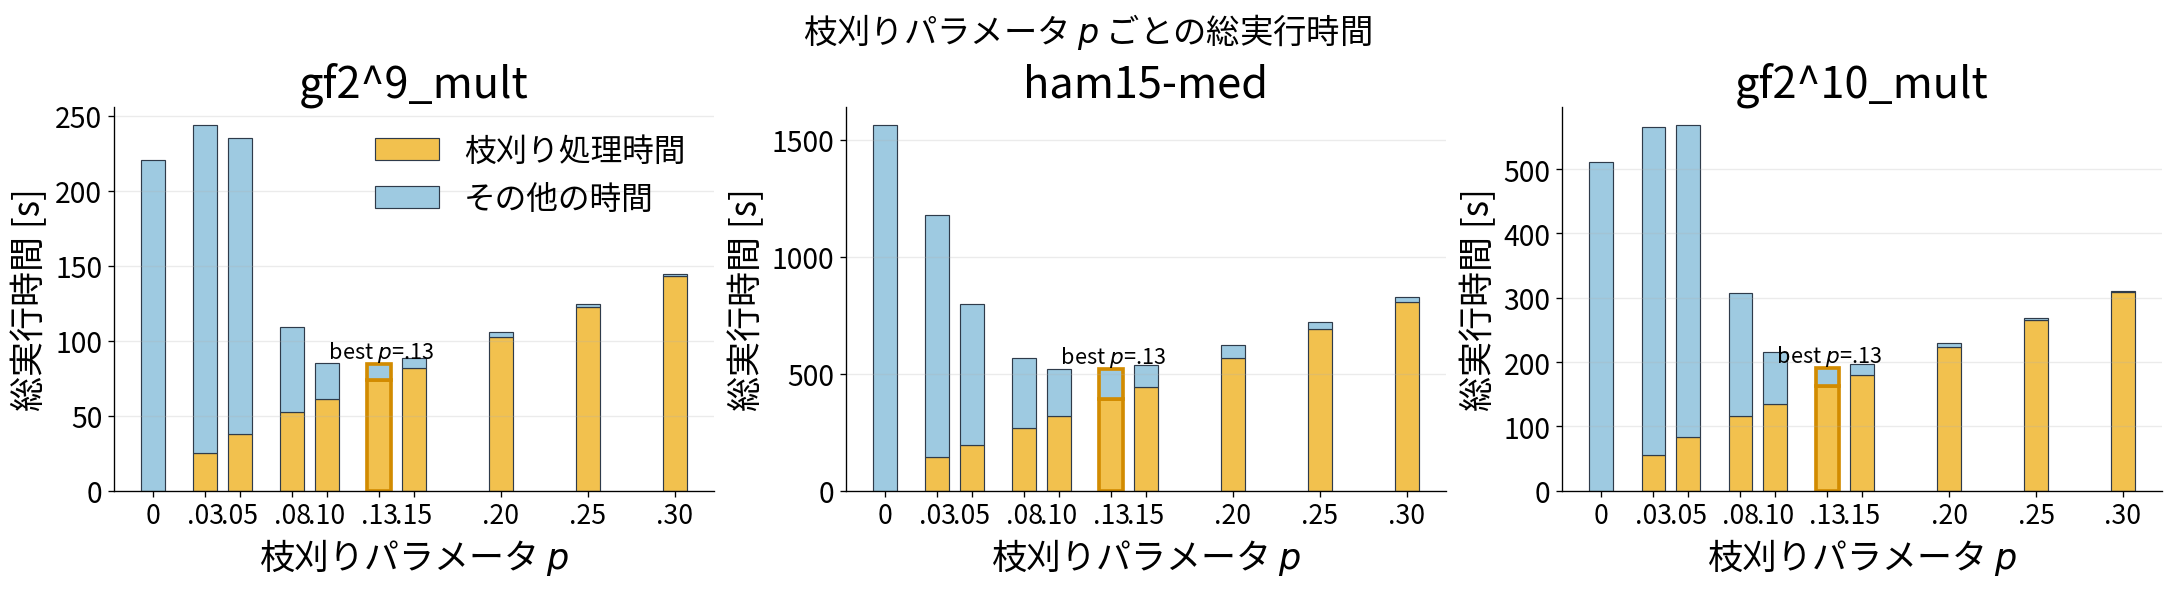

In [106]:
def plot_total_time_by_p(results, out_base=FIG_DIR / "pruning_reuse_total_time_by_p"):
    fig, axes = plt.subplots(1, len(results), figsize=(18, 4.8), constrained_layout=True)
    if len(results) == 1:
        axes = [axes]

    for ax, (label, rows) in zip(axes, results.items()):
        ps = [row["p"] for row in rows]
        times = [row["total_s"] for row in rows]
        prune_times = [row["prune_time_s"] for row in rows]
        other_times = [max(total - prune, 0.0) for total, prune in zip(times, prune_times)]
        if not rows:
            ax.set_title(label)
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        best_idx = min(range(len(times)), key=times.__getitem__)
        edgecolors = ["#2f3b4a"] * len(rows)
        linewidths = [0.7] * len(rows)
        edgecolors[best_idx] = "#d28b00"
        linewidths[best_idx] = 2.2

        x = [p / 100.0 for p in ps]
        bar_width = 0.0135
        ax.bar(x, prune_times, width=bar_width, color="#f2c14e", edgecolor=edgecolors, linewidth=linewidths, label="枝刈り処理時間")
        ax.bar(x, other_times, width=bar_width, bottom=prune_times, color="#9ecae1", edgecolor=edgecolors, linewidth=linewidths, label="その他の時間")
        tick_labels = ["0" if value == 0 else f"{value:.2f}".lstrip("0") for value in x]
        ax.set_xticks(x, tick_labels, rotation=0, ha="center")
        ax.set_title(label)
        ax.set_xlabel("枝刈りパラメータ $p$")
        ax.set_ylabel("総実行時間 [s]")
        ax.grid(axis="y", alpha=0.25)
        ax.text(
            x[best_idx],
            times[best_idx],
            f" best $p$={f'{x[best_idx]:.2f}'.lstrip('0')}",
            ha="center",
            va="bottom",
            fontsize=13,
        )

    axes[0].legend(frameon=False, loc="upper right")
    fig.suptitle("枝刈りパラメータ $p$ ごとの総実行時間")
    fig.savefig(out_base.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
    return fig


fig1 = plot_total_time_by_p(results)

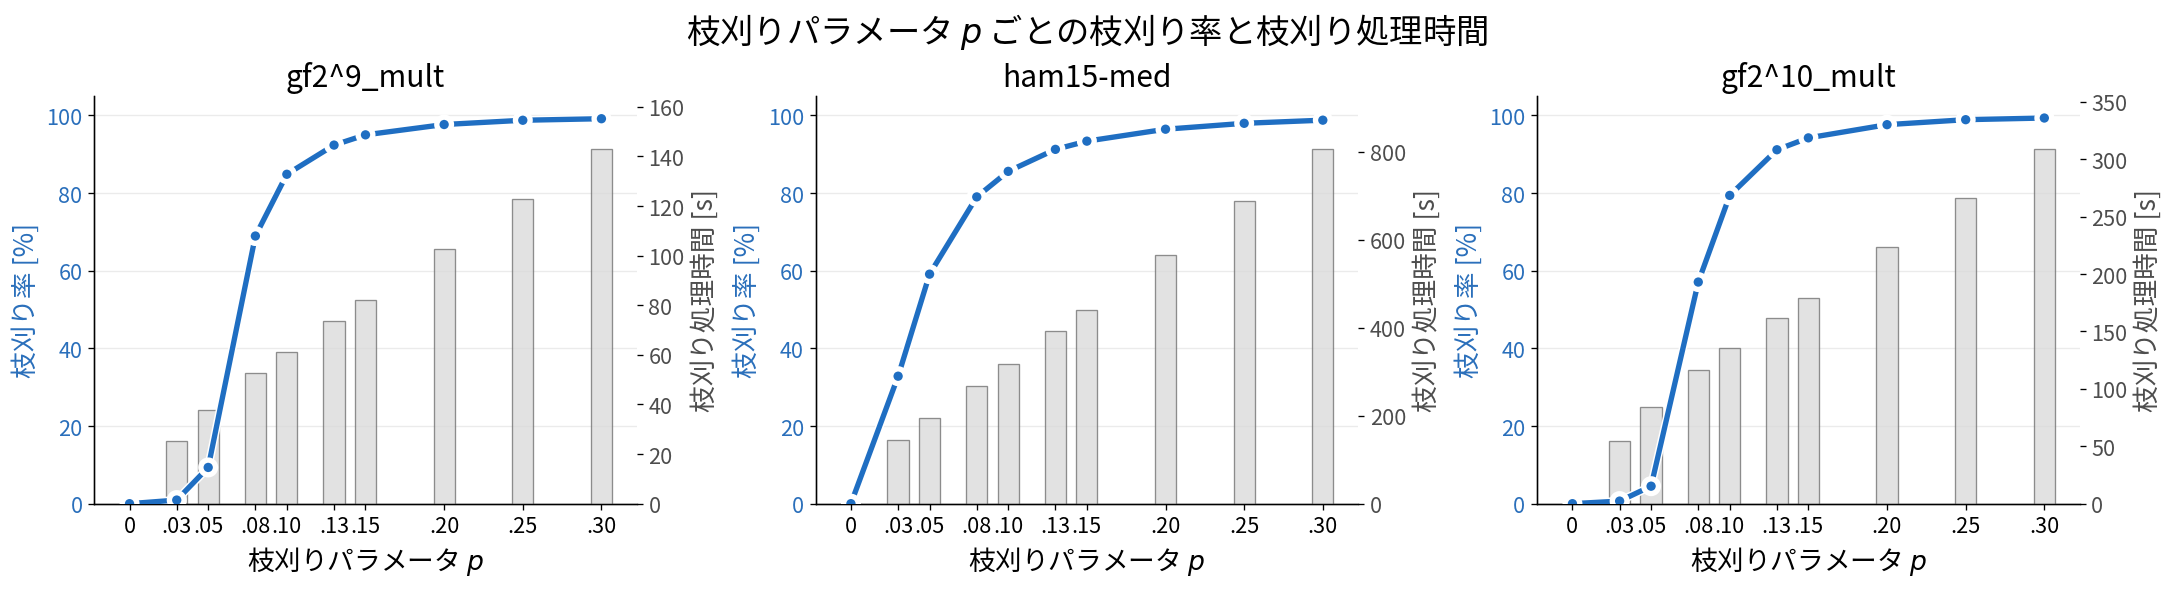

In [102]:
def plot_pruning_rate_and_time(results, out_base=FIG_DIR / "pruning_reuse_rate_and_pruning_time_by_p"):
    fig, axes = plt.subplots(1, len(results), figsize=(18, 4.8), constrained_layout=True)
    if len(results) == 1:
        axes = [axes]

    for ax, (label, rows) in zip(axes, results.items()):
        if not rows:
            ax.set_title(label)
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ps = [row["p"] for row in rows]
        x = [p / 100.0 for p in ps]
        rates = [row["prune_rate_pct"] for row in rows]
        prune_times = [row["prune_time_s"] for row in rows]

        ax2 = ax.twinx()
        right_ylim = max(prune_times) * 1.15 if max(prune_times) > 0 else 1.0
        scaled_rates = [rate / 105.0 * right_ylim for rate in rates]
        bars = ax2.bar(x, prune_times, width=0.0135, color="#d9d9d9", edgecolor="#6b6b6b", linewidth=0.8, alpha=0.75, label="枝刈り処理時間", zorder=1)
        line, = ax2.plot(
            x,
            scaled_rates,
            color="#1f6ec2",
            marker="o",
            markersize=7,
            markeredgewidth=1.4,
            markeredgecolor="white",
            linewidth=3.2,
            alpha=1.0,
            label="枝刈り率",
            zorder=20,
        )
        line.set_path_effects([pe.Stroke(linewidth=5.0, foreground="white"), pe.Normal()])

        ax.set_title(label)
        ax.set_xlabel("枝刈りパラメータ $p$")
        tick_labels = ["0" if value == 0 else f"{value:.2f}".lstrip("0") for value in x]
        ax.set_xticks(x, tick_labels, rotation=0, ha="center")
        ax.set_ylabel("枝刈り率 [%]", color="#2a6fbb")
        ax.tick_params(axis="y", labelcolor="#2a6fbb")
        ax.set_ylim(0, 105)
        ax.grid(axis="y", alpha=0.25)

        ax2.set_ylabel("枝刈り処理時間 [s]", color="#4d4d4d")
        ax2.tick_params(axis="y", labelcolor="#4d4d4d")
        ax2.set_ylim(0, right_ylim)

    fig.suptitle("枝刈りパラメータ $p$ ごとの枝刈り率と枝刈り処理時間")
    fig.savefig(out_base.with_suffix(".png"), dpi=300)
    fig.savefig(out_base.with_suffix(".pdf"))
    return fig


fig2 = plot_pruning_rate_and_time(results)

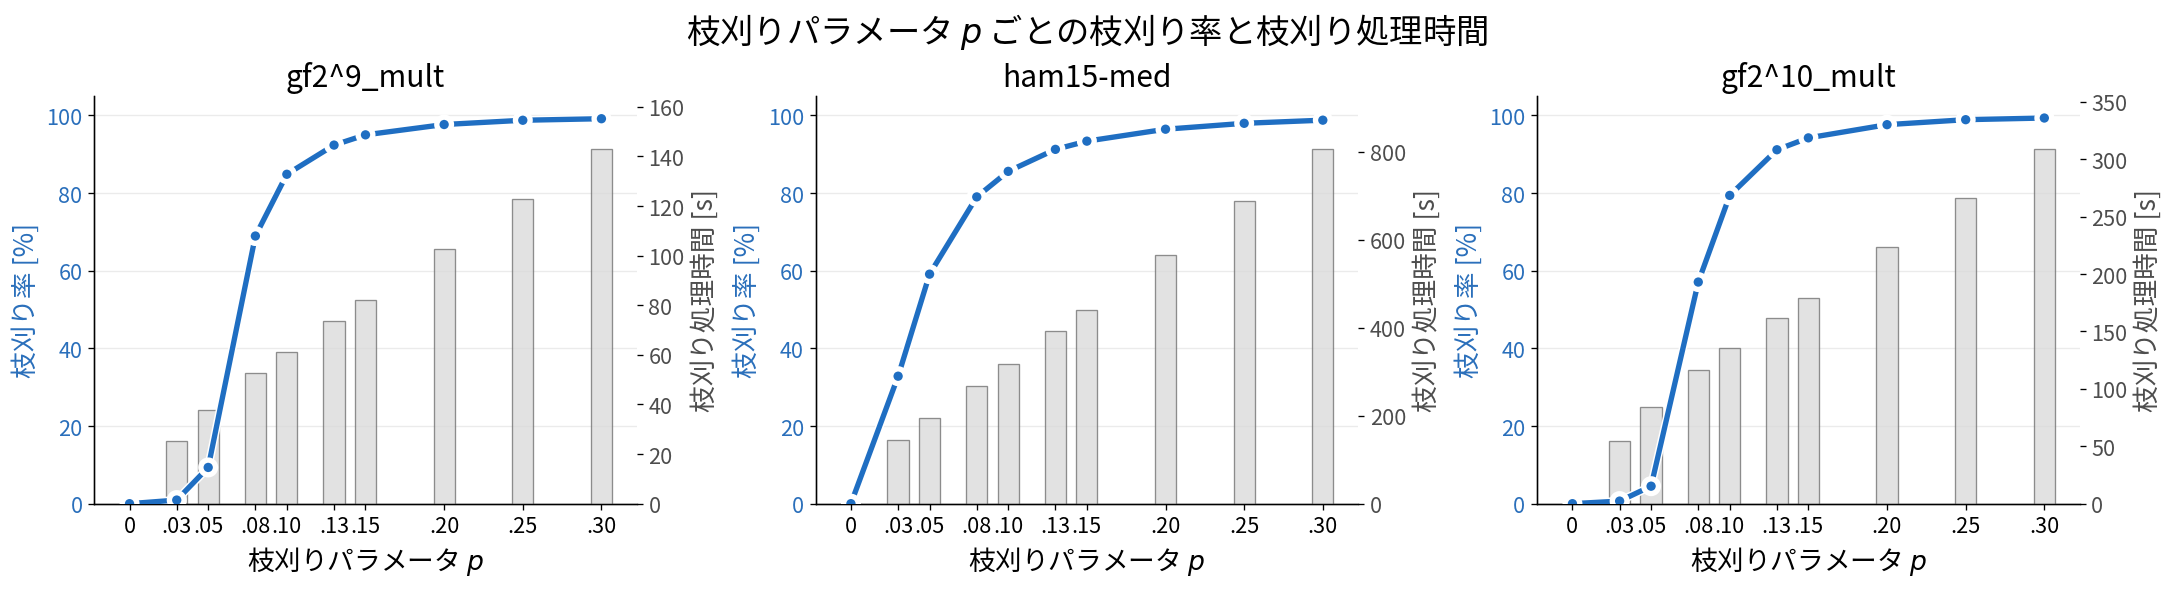

In [103]:
def plot_pruning_rate_and_time(results, out_base=FIG_DIR / "pruning_reuse_rate_and_pruning_time_by_p"):
    fig, axes = plt.subplots(1, len(results), figsize=(18, 4.8), constrained_layout=True)
    if len(results) == 1:
        axes = [axes]

    for ax, (label, rows) in zip(axes, results.items()):
        if not rows:
            ax.set_title(label)
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ps = [row["p"] for row in rows]
        x = [p / 100.0 for p in ps]
        rates = [row["prune_rate_pct"] for row in rows]
        prune_times = [row["prune_time_s"] for row in rows]

        ax2 = ax.twinx()
        right_ylim = max(prune_times) * 1.15 if max(prune_times) > 0 else 1.0
        scaled_rates = [rate / 105.0 * right_ylim for rate in rates]
        bars = ax2.bar(x, prune_times, width=0.0135, color="#d9d9d9", edgecolor="#6b6b6b", linewidth=0.8, alpha=0.75, label="枝刈り処理時間", zorder=1)
        line, = ax2.plot(
            x,
            scaled_rates,
            color="#1f6ec2",
            marker="o",
            markersize=7,
            markeredgewidth=1.4,
            markeredgecolor="white",
            linewidth=3.2,
            alpha=1.0,
            label="枝刈り率",
            zorder=20,
        )
        line.set_path_effects([pe.Stroke(linewidth=5.0, foreground="white"), pe.Normal()])

        ax.set_title(label)
        ax.set_xlabel("枝刈りパラメータ $p$")
        tick_labels = ["0" if value == 0 else f"{value:.2f}".lstrip("0") for value in x]
        ax.set_xticks(x, tick_labels, rotation=0, ha="center")
        ax.set_ylabel("枝刈り率 [%]", color="#2a6fbb")
        ax.tick_params(axis="y", labelcolor="#2a6fbb")
        ax.set_ylim(0, 105)
        ax.grid(axis="y", alpha=0.25)

        ax2.set_ylabel("枝刈り処理時間 [s]", color="#4d4d4d")
        ax2.tick_params(axis="y", labelcolor="#4d4d4d")
        ax2.set_ylim(0, right_ylim)

    fig.suptitle("枝刈りパラメータ $p$ ごとの枝刈り率と枝刈り処理時間")
    fig.savefig(out_base.with_suffix(".png"), dpi=300)
    fig.savefig(out_base.with_suffix(".pdf"))
    return fig


fig2 = plot_pruning_rate_and_time(results)

In [104]:
# Optional: print the numeric values used in the figures.
for label, rows in results.items():
    print(f"\n{label}")
    print("p\ttotal[s]\tprune_rate[%]\tprune_time[s]\tprune_share[%]")
    for row in rows:
        share = 100.0 * row['prune_time_s'] / row['total_s'] if row['total_s'] > 0 else 0.0
        print(f"{row['p']}\t{row['total_s']:.3f}\t{row['prune_rate_pct']:.3f}\t{row['prune_time_s']:.3f}\t{share:.3f}")


gf2^9_mult
p	total[s]	prune_rate[%]	prune_time[s]	prune_share[%]
0	220.379	0.000	0.000	0.000
3	244.064	0.927	25.075	10.274
5	235.394	9.332	37.950	16.122
8	108.884	68.936	52.667	48.370
10	84.853	84.842	61.289	72.229
13	84.182	92.357	73.813	87.682
15	88.504	94.997	82.088	92.751
20	105.822	97.655	102.578	96.934
25	124.746	98.753	122.796	98.437
30	144.304	99.150	142.951	99.062

ham15-med
p	total[s]	prune_rate[%]	prune_time[s]	prune_share[%]
0	1563.495	0.000	0.000	0.000
3	1176.928	32.831	144.439	12.273
5	796.710	59.116	194.374	24.397
8	567.673	79.012	268.275	47.259
10	521.509	85.592	317.637	60.907
13	519.584	91.259	391.952	75.436
15	537.635	93.373	441.218	82.066
20	620.960	96.446	566.183	91.179
25	721.857	97.966	688.860	95.429
30	829.061	98.776	806.386	97.265

gf2^10_mult
p	total[s]	prune_rate[%]	prune_time[s]	prune_share[%]
0	510.345	0.000	0.000	0.000
3	565.335	0.663	54.834	9.699
5	568.924	4.503	83.755	14.722
8	307.845	57.079	116.616	37.881
10	216.007	79.397	135.317	62.645
13	191.154	91.1

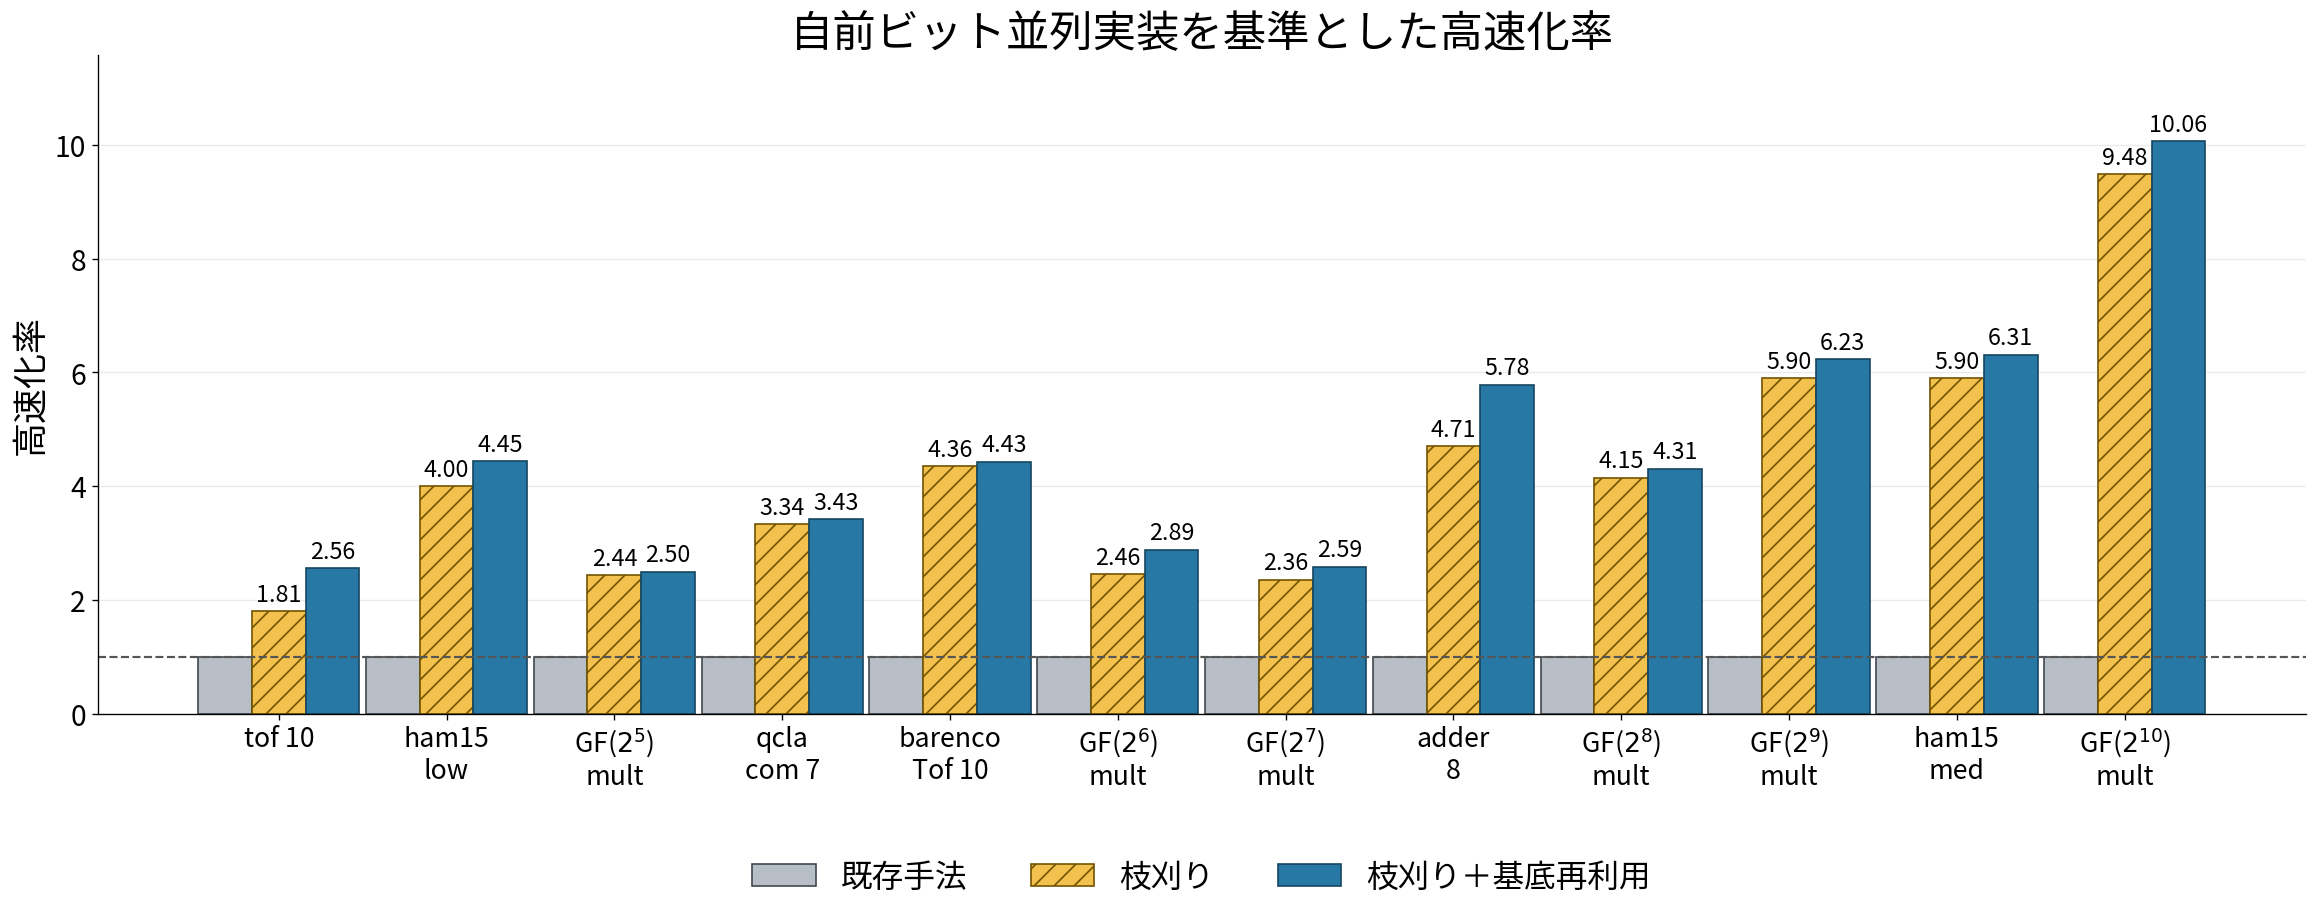

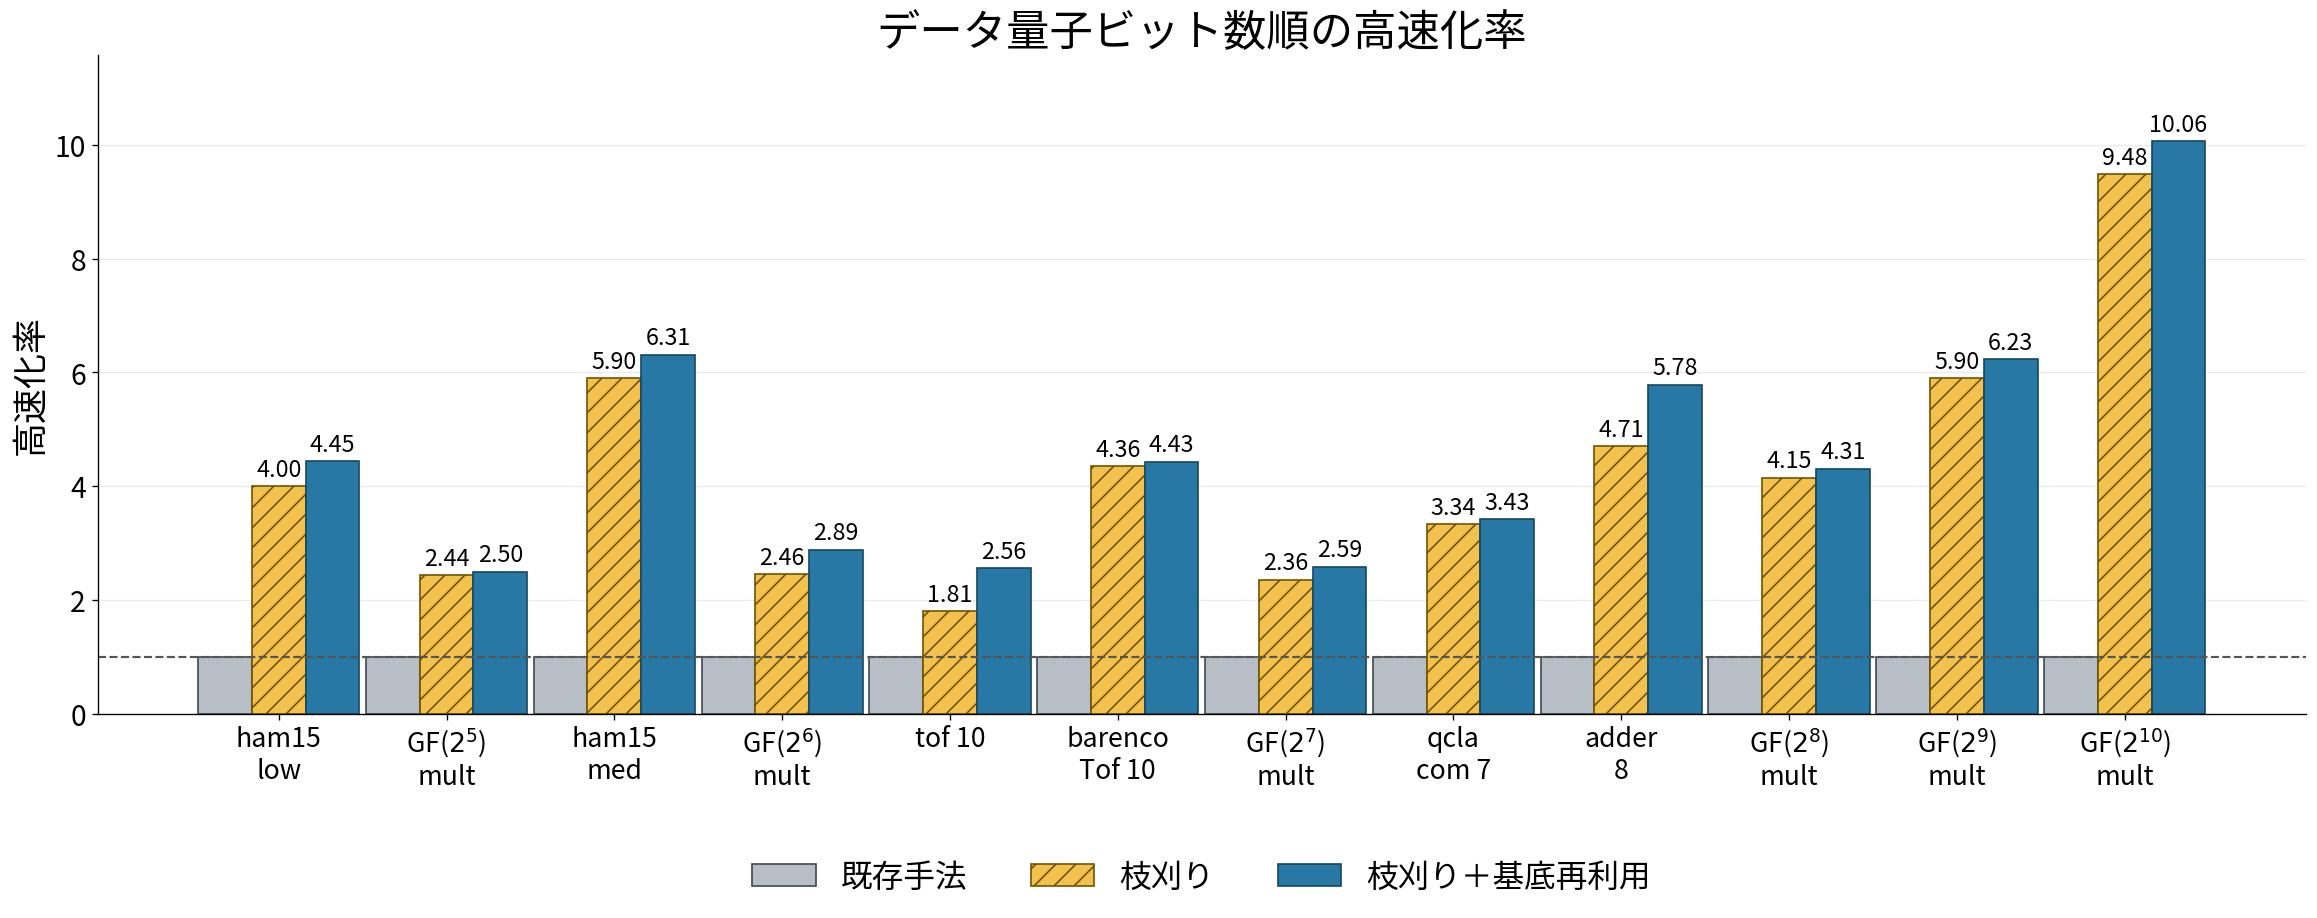

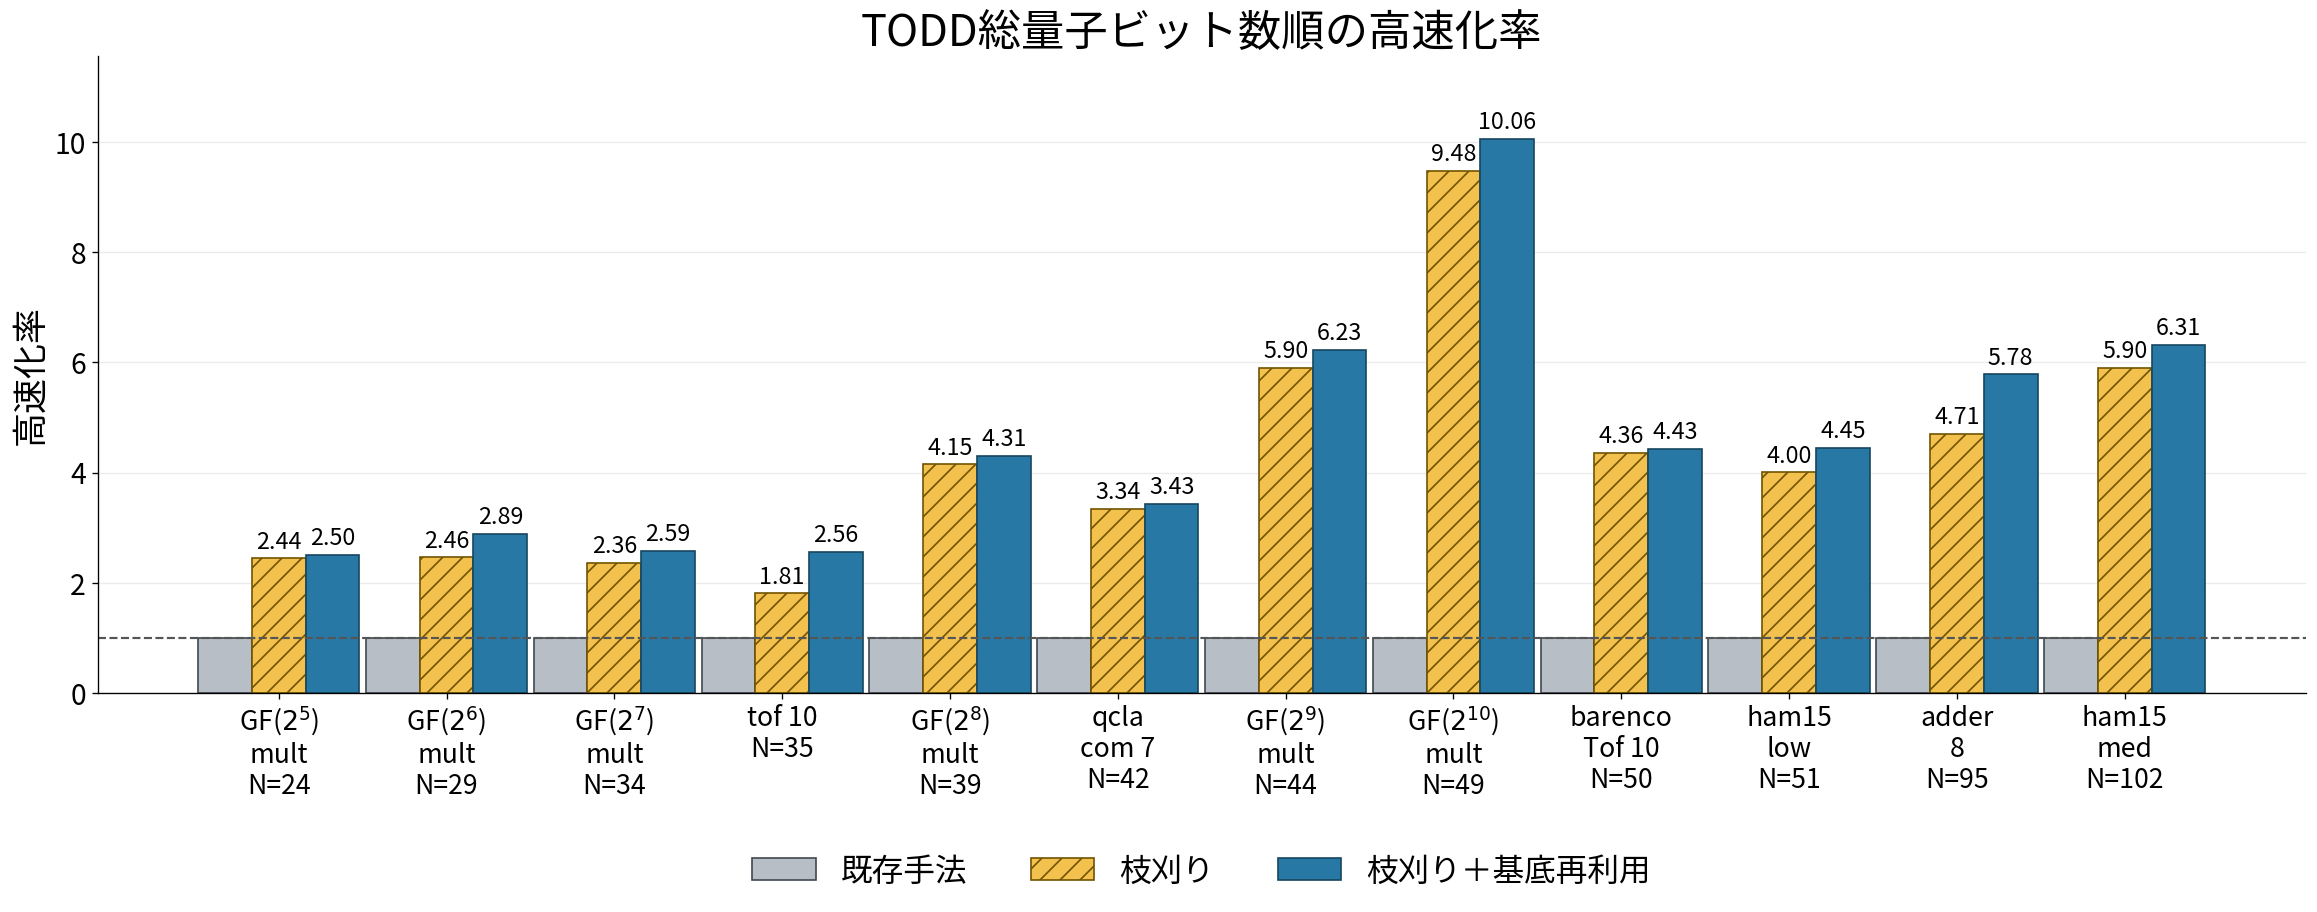

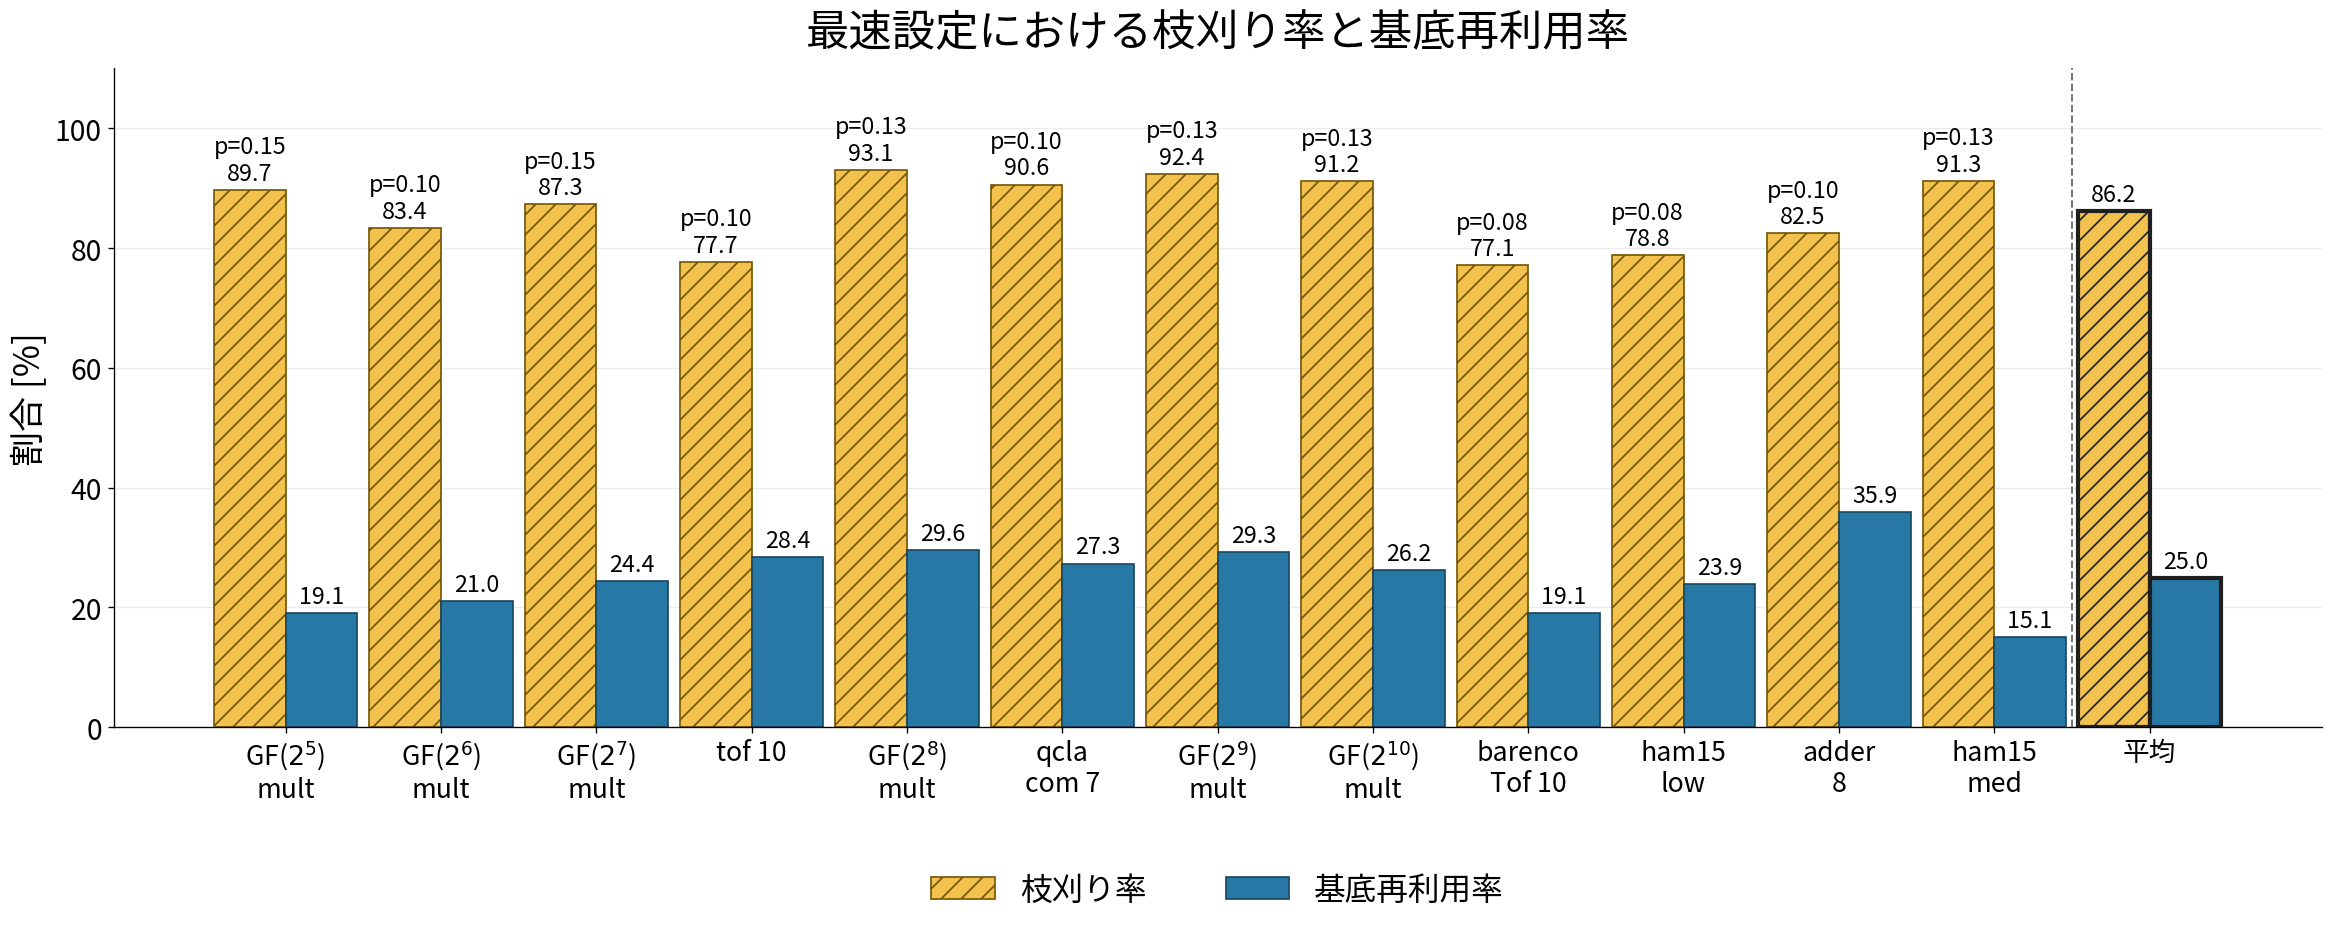

Mean pruning rate: 86.245%
Mean basis reuse success rate: 24.951%


In [105]:
import numpy as np
import matplotlib.pyplot as plt

# Bit-parallel times come from the comparison table; gf2^10 uses
# slurm-gf210-bitparallel.out. Pruning times are the fastest p values
# in the slurm-64 and slurm-65 summary CSV files.
benchmark_data = [
    # label, bit-parallel [s], pruning [s], pruning + basis reuse [s]
    ("tof 10",                  2.552,   1.411,   0.995),
    ("ham15\nlow",             21.460,   5.360,   4.827),
    (r"GF($2^5$)" "\nmult",   4.062,   1.663,   1.623),
    ("qcla\ncom 7",              9.302,   2.789,   2.715),
    ("barenco\nTof 10",        26.419,   6.065,   5.959),
    (r"GF($2^6$)" "\nmult",   9.992,   4.060,   3.460),
    (r"GF($2^7$)" "\nmult",  39.759,  16.847,  15.374),
    ("adder\n8",              1065.080, 226.258, 184.196),
    (r"GF($2^8$)" "\nmult", 132.940,  32.033,  30.845),
    (r"GF($2^9$)" "\nmult", 524.450,  88.904,  84.182),
    ("ham15\nmed",           3280.924, 555.952, 519.584),
    (r"GF($2^{10}$)" "\nmult", 1922.330, 202.830, 191.154),
]

circuits = [row[0] for row in benchmark_data]
bitparallel = [1.0] * len(benchmark_data)
pruning = [row[1] / row[2] for row in benchmark_data]
prune_reuse = [row[1] / row[3] for row in benchmark_data]

speedup_spacing = 0.78
x = np.arange(len(circuits)) * speedup_spacing
width = 0.25

plt.rcParams.update({
    "font.family": "Noto Sans CJK JP",
    "font.size": 18,
    "axes.titlesize": 26,
    "axes.labelsize": 21,
    "xtick.labelsize": 16,
    "ytick.labelsize": 17,
    "legend.fontsize": 19,
})

fig, ax = plt.subplots(figsize=(20, 9))
fig.subplots_adjust(left=0.07, right=0.99, top=0.88, bottom=0.27)

bars1 = ax.bar(
    x - width, bitparallel, width,
    label="既存手法",
    color="#b8bec5", edgecolor="#3f4850"
)
bars2 = ax.bar(
    x, pruning, width,
    label="枝刈り",
    color="#f2c14e", edgecolor="#725400",
    hatch="//"
)
bars3 = ax.bar(
    x + width, prune_reuse, width,
    label="枝刈り＋基底再利用",
    color="#2878a5", edgecolor="#17465f"
)

# 基準となる高速化率1.0
ax.axhline(1.0, color="#555555", linestyle="--", linewidth=1.3)

ax.set_title("自前ビット並列実装を基準とした高速化率")
ax.set_ylabel("高速化率")
ax.set_xticks(x, circuits, fontsize=16)
ax.tick_params(axis="y", labelsize=17)
ax.set_ylim(0, max(prune_reuse) * 1.15)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False)

# 棒の上に数値を表示
for bars in (bars2, bars3):
    ax.bar_label(
        bars,
        labels=[f"{bar.get_height():.2f}" for bar in bars],
        padding=3,
        fontsize=14,
        rotation=0
    )

fig.savefig(FIG_DIR / "benchmark_speedup.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "benchmark_speedup.pdf", bbox_inches="tight")

plt.show()

# Alternative view: sort by the number of qubits. T-gate order is used
# as the tie-breaker because benchmark_data is already T-count sorted.
qubit_counts = [19, 15, 15, 24, 19, 18, 21, 24, 24, 27, 17, 30]
qubit_order = sorted(range(len(benchmark_data)), key=lambda i: qubit_counts[i])
circuits_n = [circuits[i] for i in qubit_order]
bitparallel_n = [bitparallel[i] for i in qubit_order]
pruning_n = [pruning[i] for i in qubit_order]
prune_reuse_n = [prune_reuse[i] for i in qubit_order]
x_n = np.arange(len(circuits_n)) * speedup_spacing

fig_n, ax_n = plt.subplots(figsize=(20, 9))
fig_n.subplots_adjust(left=0.07, right=0.99, top=0.88, bottom=0.27)
bars1_n = ax_n.bar(
    x_n - width, bitparallel_n, width,
    label="既存手法",
    color="#b8bec5", edgecolor="#3f4850"
)
bars2_n = ax_n.bar(
    x_n, pruning_n, width,
    label="枝刈り",
    color="#f2c14e", edgecolor="#725400", hatch="//"
)
bars3_n = ax_n.bar(
    x_n + width, prune_reuse_n, width,
    label="枝刈り＋基底再利用",
    color="#2878a5", edgecolor="#17465f"
)
ax_n.axhline(1.0, color="#555555", linestyle="--", linewidth=1.3)
ax_n.set_title("データ量子ビット数順の高速化率")
ax_n.set_ylabel("高速化率")
ax_n.set_xticks(x_n, circuits_n, fontsize=16)
ax_n.tick_params(axis="y", labelsize=17)
ax_n.set_ylim(0, max(prune_reuse_n) * 1.15)
ax_n.grid(axis="y", alpha=0.25)
ax_n.set_axisbelow(True)
ax_n.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False)
for bars in (bars2_n, bars3_n):
    ax_n.bar_label(
        bars,
        labels=[f"{bar.get_height():.2f}" for bar in bars],
        padding=3,
        fontsize=14,
        rotation=0,
    )

fig_n.savefig(FIG_DIR / "benchmark_speedup_by_qubits.png", dpi=300, bbox_inches="tight")
fig_n.savefig(FIG_DIR / "benchmark_speedup_by_qubits.pdf", bbox_inches="tight")
plt.show()

# TODD-internal size: data qubits plus Hadamard ancillas reported by the
# slurm-64/slurm-65 output logs.
todd_total_qubits = [35, 51, 24, 42, 50, 29, 34, 95, 39, 44, 102, 49]
todd_order = sorted(range(len(benchmark_data)), key=lambda i: todd_total_qubits[i])
circuits_todd = [f"{circuits[i]}\nN={todd_total_qubits[i]}" for i in todd_order]
bitparallel_todd = [bitparallel[i] for i in todd_order]
pruning_todd = [pruning[i] for i in todd_order]
prune_reuse_todd = [prune_reuse[i] for i in todd_order]
x_todd = np.arange(len(circuits_todd)) * speedup_spacing

fig_todd, ax_todd = plt.subplots(figsize=(20, 9))
fig_todd.subplots_adjust(left=0.07, right=0.99, top=0.88, bottom=0.29)
bars1_todd = ax_todd.bar(
    x_todd - width, bitparallel_todd, width,
    label="既存手法",
    color="#b8bec5", edgecolor="#3f4850"
)
bars2_todd = ax_todd.bar(
    x_todd, pruning_todd, width,
    label="枝刈り",
    color="#f2c14e", edgecolor="#725400", hatch="//"
)
bars3_todd = ax_todd.bar(
    x_todd + width, prune_reuse_todd, width,
    label="枝刈り＋基底再利用",
    color="#2878a5", edgecolor="#17465f"
)
ax_todd.axhline(1.0, color="#555555", linestyle="--", linewidth=1.3)
ax_todd.set_title("TODD総量子ビット数順の高速化率")
ax_todd.set_ylabel("高速化率")
ax_todd.set_xticks(x_todd, circuits_todd, fontsize=16)
ax_todd.tick_params(axis="y", labelsize=17)
ax_todd.set_ylim(0, max(prune_reuse_todd) * 1.15)
ax_todd.grid(axis="y", alpha=0.25)
ax_todd.set_axisbelow(True)
ax_todd.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.21), frameon=False)
for bars in (bars2_todd, bars3_todd):
    ax_todd.bar_label(
        bars,
        labels=[f"{bar.get_height():.2f}" for bar in bars],
        padding=3,
        fontsize=14,
        rotation=0,
    )

fig_todd.savefig(FIG_DIR / "benchmark_speedup_by_todd_qubits.png", dpi=300, bbox_inches="tight")
fig_todd.savefig(FIG_DIR / "benchmark_speedup_by_todd_qubits.pdf", bbox_inches="tight")
plt.show()

# Rates measured at the fastest pruning + basis reuse setting for each
# circuit. The order follows total TODD qubit count.
rate_data = [
    # label, pruning rate [%], basis reuse success rate [%]
    (r"GF($2^5$)" "\nmult", 89.7449, 19.120),
    (r"GF($2^6$)" "\nmult", 83.4057, 21.016),
    (r"GF($2^7$)" "\nmult", 87.3270, 24.383),
    ("tof 10",                 77.6554, 28.402),
    (r"GF($2^8$)" "\nmult", 93.0866, 29.559),
    ("qcla\ncom 7",            90.6102, 27.338),
    (r"GF($2^9$)" "\nmult", 92.3570, 29.282),
    (r"GF($2^{10}$)" "\nmult", 91.1547, 26.242),
    ("barenco\nTof 10",       77.1026, 19.100),
    ("ham15\nlow",            78.7801, 23.899),
    ("adder\n8",              82.4566, 35.943),
    ("ham15\nmed",            91.2587, 15.126),
]
best_ps = [0.15, 0.10, 0.15, 0.10, 0.13, 0.10, 0.13, 0.13, 0.08, 0.08, 0.10, 0.13]
rate_labels = [row[0] for row in rate_data]
pruning_rates = [row[1] for row in rate_data]
reuse_rates = [row[2] for row in rate_data]
mean_pruning_rate = float(np.mean(pruning_rates))
mean_reuse_rate = float(np.mean(reuse_rates))
rate_labels.append("平均")
pruning_rates.append(mean_pruning_rate)
reuse_rates.append(mean_reuse_rate)

rate_spacing = 0.78
x_rate = np.arange(len(rate_labels)) * rate_spacing
rate_width = 0.36
plt.rcParams["font.family"] = "Noto Sans CJK JP"
fig_rate, ax_rate = plt.subplots(figsize=(20, 9))
fig_rate.subplots_adjust(left=0.07, right=0.99, top=0.88, bottom=0.27)
prune_bars = ax_rate.bar(
    x_rate - rate_width / 2, pruning_rates, rate_width,
    label="枝刈り率",
    color="#f2c14e", edgecolor="#725400", hatch="//",
)
reuse_bars = ax_rate.bar(
    x_rate + rate_width / 2, reuse_rates, rate_width,
    label="基底再利用率",
    color="#2878a5", edgecolor="#17465f",
)
prune_value_labels = [
    f"p={p:.2f}\n{rate:.1f}" for rate, p in zip(pruning_rates[:-1], best_ps)
] + [f"{pruning_rates[-1]:.1f}"]
reuse_value_labels = [f"{rate:.1f}" for rate in reuse_rates]
for bars, value_labels in (
    (prune_bars, prune_value_labels),
    (reuse_bars, reuse_value_labels),
):
    bars[-1].set_linewidth(2.5)
    bars[-1].set_edgecolor("#1f1f1f")
    ax_rate.bar_label(
        bars,
        labels=value_labels,
        padding=3,
        fontsize=14,
        rotation=0,
    )
ax_rate.axvline(x_rate[-1] - rate_spacing / 2, color="#777777", linestyle="--", linewidth=1.2)
ax_rate.set_title("最速設定における枝刈り率と基底再利用率", fontsize=26, pad=14)
ax_rate.set_ylabel("割合 [%]", fontsize=21)
ax_rate.set_xticks(x_rate, rate_labels, fontsize=16)
ax_rate.tick_params(axis="y", labelsize=17)
ax_rate.set_ylim(0, 110)
ax_rate.grid(axis="y", alpha=0.25)
ax_rate.set_axisbelow(True)
ax_rate.legend(
    ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18),
    frameon=False, fontsize=19, columnspacing=2.5, handlelength=2.0,
)
fig_rate.savefig(FIG_DIR / "benchmark_pruning_and_reuse_rates.png", dpi=300, bbox_inches="tight")
fig_rate.savefig(FIG_DIR / "benchmark_pruning_and_reuse_rates.pdf", bbox_inches="tight")
fig_rate.savefig(FIG_DIR / "benchmark_pruning_and_reuse_rates_with_p.png", dpi=300, bbox_inches="tight")
fig_rate.savefig(FIG_DIR / "benchmark_pruning_and_reuse_rates_with_p.pdf", bbox_inches="tight")
plt.show()
print(f"Mean pruning rate: {mean_pruning_rate:.3f}%")
print(f"Mean basis reuse success rate: {mean_reuse_rate:.3f}%")